# Worshop 12 - Supervised Learning

In this workshop we will be using the simulated dataset I created for week 10 and fitting supservised machine learning models like logistic regression and random forest models

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/hdg204/DoctorsAsDataScientists/main/metabolic_data.csv"
df = pd.read_csv(url)

We already understand this data from week 10 so you should already be familiar with the variables inlcluded. We don't need to worry about exploring data we already understand, so we'll just jump straight into modelling for this workshop. We will be using a random forest classifier to predict diabetes using metabolic and genetic factors.

## Hour 1 - Random Forest Classifiers

### Part 1
Create a feature matrix `x_df` consisting of dbp, sbp, hdl, ldl, tdi, bmi, and t2d_grs

In [ ]:
cols = ["dbp", "sbp", "hdl", "ldl", "tdi", "bmi", "t2d_grs"]
x_df = df[cols]

### Part 2
Create a targets vector `y_df` using the diabetes column

In [ ]:
y_df = df['diabetes']

### Part 3

Set up a random forest classifier to classify use your feature matrix and target vector to build a random forest model of diabetes

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier(n_estimators=50)
rf_model.fit(x_df,y_df)
y_pred=rf_model.predict(x_df)

### Part 4

Compute and display the confusion matrix

In [ ]:
#Your code here

### Part 5

Identify the most important features for predicting diabetes based on your model, and plot a graph to visualise this

/tmp/ipykernel_329978/1912017332.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp,y=feat_imp.index,palette="Set2")


Text(0, 0.5, 'Feature')

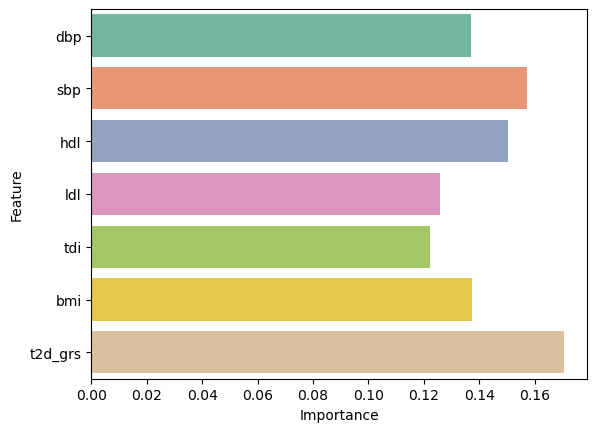

In [6]:
feat_imp=pd.Series(rf_model.feature_importances_,index=x_df.columns)
sns.barplot(x=feat_imp,y=feat_imp.index,palette="Set2")
plt.xlabel("Importance")
plt.ylabel("Feature")

### Part 6

Repeat the previous task, but with a 80/20 test/train split, and report the new confusion matrix

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    x_df, y_df, test_size=0.2, random_state=42, stratify=y_df
)
rf_model=RandomForestClassifier(n_estimators=50)
rf_model.fit(X_train,y_train)
y_pred=rf_model.predict(X_test)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91      8374
           1       0.52      0.12      0.20      1626

    accuracy                           0.84     10000
   macro avg       0.69      0.55      0.55     10000
weighted avg       0.80      0.84      0.79     10000

[[8197  177]
 [1431  195]]


### Part 7

Exclude participants of white ethnicity from the dataframe and then rerun the model.

Compare the accuracy of the model and the important features vs the model of mostly white participants.

/tmp/ipykernel_329978/3174881362.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp,y=feat_imp.index,palette="Set2")


              precision    recall  f1-score   support

           0       0.83      0.98      0.90      2040
           1       0.46      0.09      0.15       440

    accuracy                           0.82      2480
   macro avg       0.65      0.53      0.53      2480
weighted avg       0.77      0.82      0.77      2480

[[1993   47]
 [ 400   40]]


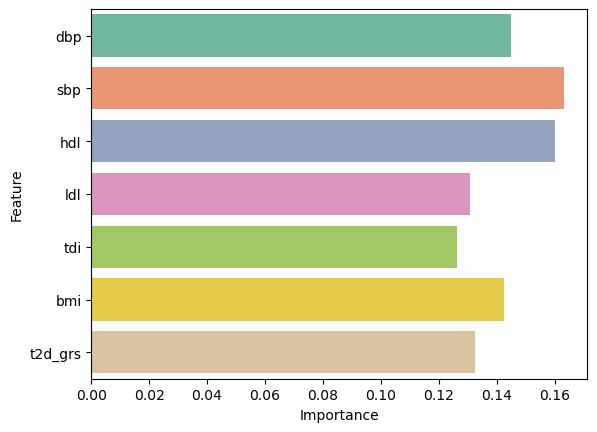

In [10]:
#filtering to nonwhite ethnicity
df_nonwhite=df[df['ethnicity']!='White']
x_df_nonwhite = df_nonwhite[cols]
y_df_nonwhite = df_nonwhite['diabetes']
#fitting rf model
rf_model=RandomForestClassifier(n_estimators=50)
rf_model.fit(x_df_nonwhite,y_df_nonwhite)
y_pred_nonwhite=rf_model.predict(x_df_nonwhite)
#feature importance
feat_imp=pd.Series(rf_model.feature_importances_,index=x_df.columns)
sns.barplot(x=feat_imp,y=feat_imp.index,palette="Set2")
plt.xlabel("Importance")
plt.ylabel("Feature")
#confusion matrix and accuracy
X_train, X_test, y_train, y_test = train_test_split(
    x_df_nonwhite, y_pred_nonwhite, test_size=0.2, random_state=42, stratify=y_pred_nonwhite
)
rf_model=RandomForestClassifier(n_estimators=50)
rf_model.fit(X_train,y_train)
y_pred=rf_model.predict(X_test)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

## Group Task

From 13:30, we will split into groups of 2-4 people. Using all the simulated data we have available to us, build a random forest classifier or a linear model of a variable of your choice. If you want to predict hypertension or myocardial infarction, you may choose to turn this date variable into a binary variable, using for example, 

`df['mi']=df['mi_date'].notna()`

at 14:10, each group will have 5 minutes to present their model to the rest of the class.

Things you may wish to consider:

* How does ethnicity impact which features are important for prediction
* Which other features might be useful for improving predictive performance
* How well can we predict another disease recorded in the data